# Sidequest - Polynomial Regression

This is a side quest for the lab 05 on jan 30. The task was to implement a polynomial regressor from scratch

## Overview
Polynomial Regression is an extension of linear regression that models the relationship between the independent variable(s) and the dependent variable as an nth-degree polynomial. While linear regression fits a straight line to the data, polynomial regression can capture non-linear patterns by introducing polynomial terms.

## Mathematical Formulation

For a single feature, the polynomial regression model is:

$$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \beta_3 x^3 + ... + \beta_n x^n + \epsilon$$

Where:
- $y$ is the dependent variable (target)
- $x$ is the independent variable (feature)
- $\beta_0, \beta_1, ..., \beta_n$ are the coefficients (weights)
- $n$ is the degree of the polynomial
- $\epsilon$ is the error term

## Feature Transformation

Polynomial regression transforms the original features into polynomial features:

For input $X = [x_1, x_2, ..., x_m]$ with degree $n$:
- Original features: $x_1, x_2, ..., x_m$
- Polynomial features: $x_1, x_1^2, ..., x_1^n, x_2, x_2^2, ..., x_2^n, ...$

## Cost Function

The Mean Squared Error (MSE) loss function:

$$J(\beta) = \frac{1}{2m} \sum_{i=1}^{m} (h_\beta(x^{(i)}) - y^{(i)})^2$$

Where:
- $m$ is the number of training samples
- $h_\beta(x^{(i)})$ is the predicted value
- $y^{(i)}$ is the actual value

## Gradient Descent

To minimize the cost function, we use gradient descent:

$$\beta_j := \beta_j - \alpha \frac{\partial J(\beta)}{\partial \beta_j}$$

The gradient for each weight:

$$\frac{\partial J(\beta)}{\partial \beta_j} = \frac{1}{m} \sum_{i=1}^{m} (h_\beta(x^{(i)}) - y^{(i)}) \cdot x_j^{(i)}$$

Where:
- $\alpha$ is the learning rate
- $\beta_j$ is the j-th coefficient

## Feature Scaling

**Why it's important:**
- Polynomial features can have vastly different magnitudes (e.g., $x$ vs $x^2$ vs $x^3$)
- Large feature values lead to exploding gradients
- Feature scaling ensures faster and more stable convergence

**Standardization formula:**

$$x_{scaled} = \frac{x - \mu}{\sigma}$$

Where:
- $\mu$ is the mean of the feature
- $\sigma$ is the standard deviation

## Key Considerations

### Choosing the Degree
- **Low degree (1-2)**: May underfit; cannot capture complex patterns
- **Optimal degree**: Balances bias and variance
- **High degree**: May overfit; captures noise in training data

### Overfitting vs Underfitting
- **Underfitting**: Model is too simple, high bias, poor performance on both training and test data
- **Overfitting**: Model is too complex, high variance, excellent on training but poor on test data
- **Solution**: Use cross-validation to find optimal degree, apply regularization

### Advantages
- Can model non-linear relationships
- Still uses linear regression machinery (closed-form solutions possible)
- Interpretable for low degrees

### Disadvantages
- Sensitive to outliers
- Can overfit with high degrees
- Features can become highly correlated (multicollinearity)
- Predictions can be unreliable outside the training range (extrapolation)

## Implementation Notes

1. **Always normalize/standardize features** before polynomial expansion
2. **Store normalization parameters** (mean, std) from training data
3. **Apply same normalization** to test/prediction data
4. **Tune learning rate** carefully (typically 0.001 - 0.1)
5. **Monitor convergence** to ensure gradients don't explode

In [157]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## `PolynomialRegressor` class

In [158]:
class PolynomialRegressor:
    def __init__(self, max_degree, max_iter=1000):
        self.max_degree = max_degree
        self.max_iter = max_iter
        self.weights = None
        self.X_poly = None
        self.X_poly_cols = None
        self.mean = None
        self.std = None
        pass

    def preprocess(self, X: pd.DataFrame):
        num_samples = len(X)
        X_poly = X.copy()
        if self.mean is None:
            self.mean = X.mean()
            self.std = X.std()
        X_poly = (X_poly - self.mean) / self.std
        for column in X.columns:
            for degree in range(2, self.max_degree + 1):
                X_poly[f"{column}^{degree}"] = X_poly[column] ** degree
        X_poly["coefficient of 1"] = [1] * num_samples
        return np.array(X_poly), X_poly.columns

    def fit(self, X: pd.DataFrame, y: pd.DataFrame, learning_rate=0.01):
        num_samples = len(X)
        y = np.array(y).flatten()
        if (len(y) != num_samples):
            print(f"Invalid Shape")
            return
        self.X_poly, self.X_poly_cols = self.preprocess(X)
        self.weights = np.array([0] * len(self.X_poly_cols))
        for _ in range(self.max_iter):
            y_pred = self.predict(X, test=False)
            error = np.subtract(y_pred, y)
            gradients = np.array((2 / num_samples) * np.dot(self.X_poly.T, error)).flatten()
            self.weights = np.subtract(self.weights, learning_rate * gradients)

    def predict(self, X: pd.DataFrame, test = True):
        num_samples = len(X)
        if test:
            X_poly, X_poly_cols = self.preprocess(X)
            if (X_poly_cols != self.X_poly_cols).any():
                print(f"Columns do not match")
                return
            y_pred = np.dot(X_poly, self.weights)
        else:
            y_pred = np.dot(self.X_poly, self.weights)
        return np.array(y_pred).flatten()
    
    def evaluate(self, X: pd.DataFrame, y_true = pd.DataFrame):
        num_samples = len(X)
        y_true = np.array(y_true)
        if (len(y_true) != num_samples):
            print(f"Invalid Shape")
            return
        y_pred = self.predict(X)
        return mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred)


## Generate Random Data

Let's generate a random data to test the `PolynomialRegressor` of degree 2.

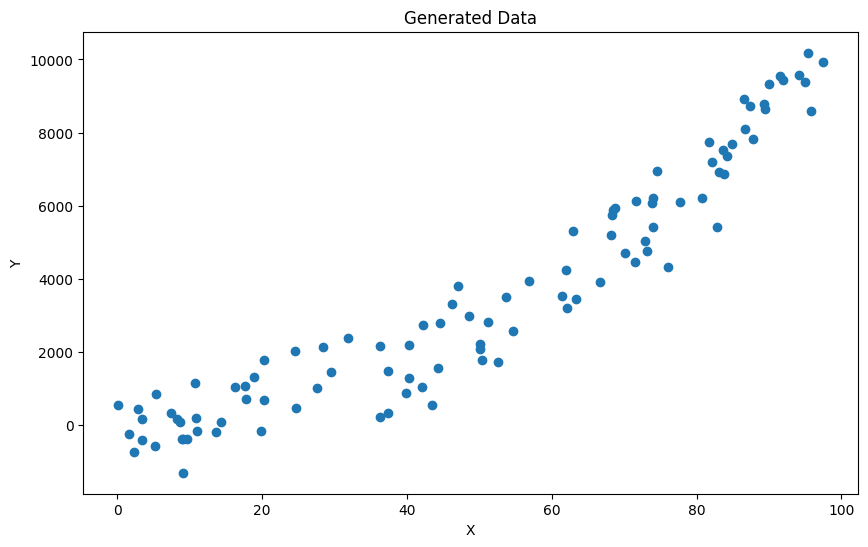

In [160]:
num_samples = 100
X = np.random.uniform(0, 100, num_samples)
y = X ** 2 + 5 * X + 10
y_noise = np.random.normal(0, 100, num_samples) * 7
y = np.add(y, y_noise)

plt.figure(figsize=(10, 6))
plt.scatter(X, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Generated Data")
plt.show()

## Usage

In [161]:
X = pd.DataFrame(X)
y = pd.DataFrame(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
model = PolynomialRegressor(max_degree=2)
model.fit(X_train, y_train)

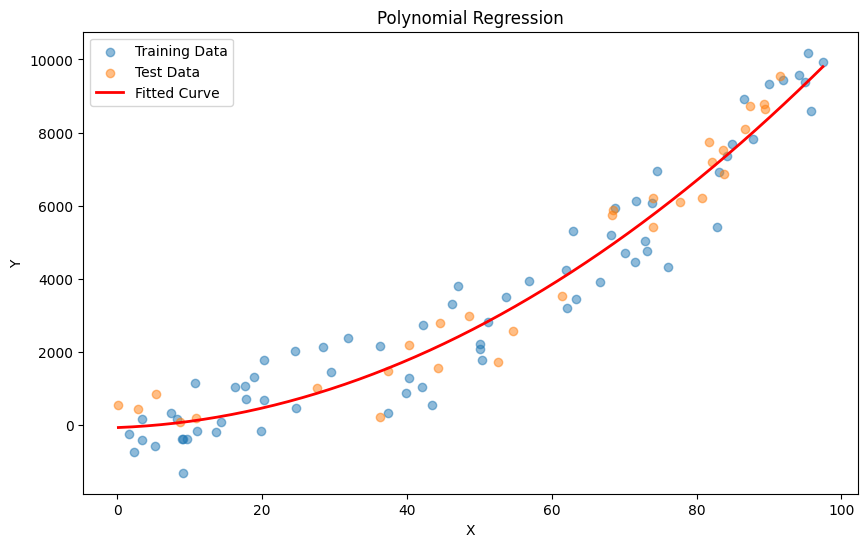

In [162]:
x_plot = np.linspace(X.min(), X.max(), num=200)
y_plot = model.predict(pd.DataFrame(x_plot))

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, alpha=0.5, label="Training Data")
plt.scatter(X_test, y_test, alpha=0.5, label="Test Data")
plt.plot(x_plot, y_plot, 'r-', linewidth=2, label="Fitted Curve")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial Regression")
plt.legend()
plt.show()